# DiT：当扩散模型遇上 Transformer — DiT: When Diffusion Meets Transformers

> **难度：** 中级 | **时间：** 约 40 分钟

自从 DDPM 以来，UNet 一直是扩散模型的默认骨干网络。但 UNet 很复杂：跨分辨率的跳跃连接、不同层级使用不同类型的模块、难以预测的扩展行为。

「扩散 Transformer」（Diffusion Transformers, DiT）用一个普通的 Transformer 替换了 UNet，带来了巨大的优势：
- **架构简洁**：统一的模块结构，不需要跨阶段的跳跃连接
- **可预测的扩展性**：性能随模型规模平滑提升（就像大语言模型一样）
- **基础设施复用**：LLM 训练中的张量并行和流水线并行技术可以直接使用

本 Notebook 涵盖：
1. 为什么要用 Transformer 替换 UNet
2. 图块化（Patchification）：把图像变成 token 序列
3. AdaLN-Zero：一种巧妙的条件注入机制
4. 完整的 DiT 架构
5. 扩展性分析
6. 为什么 DiT 是视频生成的基石

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from mp_tutorial.formatting import info_box, comparison_table
from mp_tutorial.plantuml import render_plantuml
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

---
## 1. 为什么要替换 UNet？

UNet 在扩散模型中表现不错，但在扩展性方面存在根本性的局限：

| 问题 | UNet | Transformer |
|------|------|-------------|
| **架构复杂度** | 在不同分辨率使用多种模块类型（ResBlock、Attn、CrossAttn） | 同一个模块重复 N 次 |
| **跳跃连接** | 编码器到解码器的跨分辨率连接——增加并行化难度 | 不需要 |
| **扩展行为** | 不可预测——增加参数不一定有效 | 可预测的幂律扩展（类似 GPT） |
| **并行化** | 难以跨 GPU 切分（每个阶段计算量不同） | 容易——均匀的层结构，技术成熟 |
| **基础设施** | 需要定制化的算子 | 可复用 LLM 基础设施（FlashAttention 等） |

核心洞察：**Transformer 在 LLM 领域已经有了经过验证的扩展方案。如果能让扩散模型在 Transformer 上运行，我们就能免费获得所有扩展基础设施。**

参见 [张量并行](../../en/02-tensor-parallelism.ipynb)——这就是为什么基于 Transformer 的扩散模型能更好地跨 GPU 扩展。每一层结构相同，所以可以均匀地切分模型。

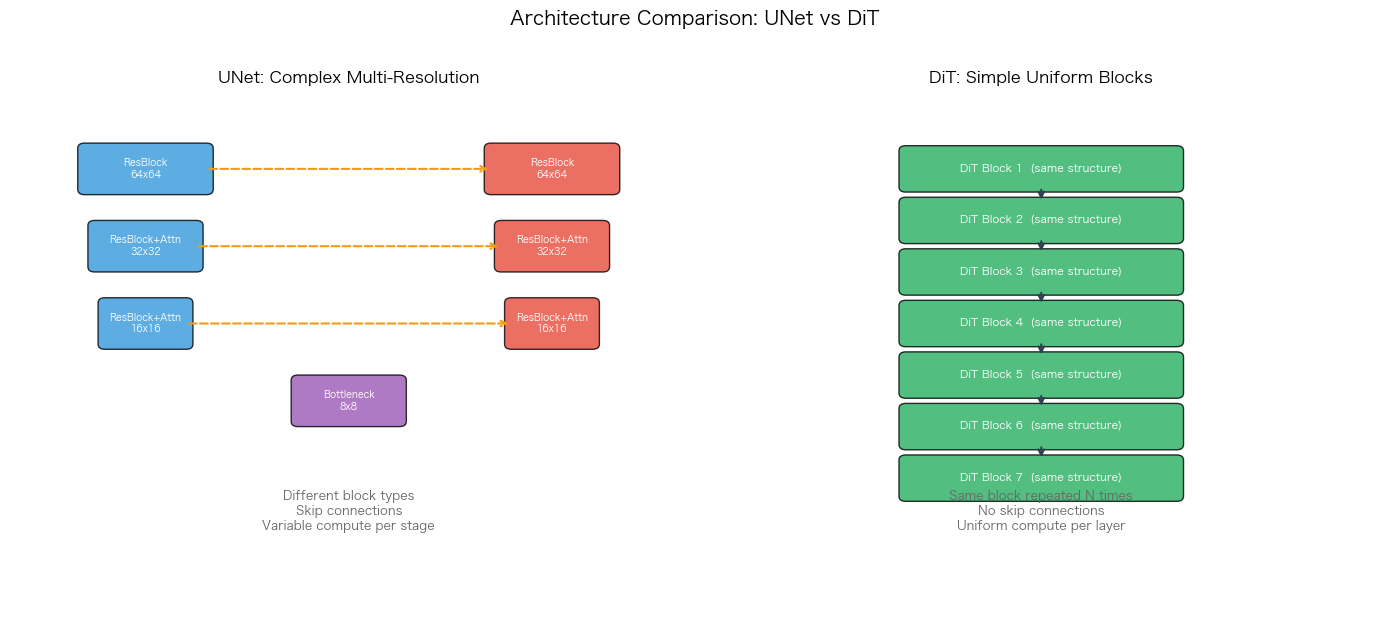

In [2]:
# Visual comparison: UNet vs DiT structure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# UNet: complex multi-resolution structure
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('UNet: Complex Multi-Resolution', fontsize=12, fontweight='bold')

# Encoder side
unet_blocks = [
    (2, 8.5, 'ResBlock\n64x64', '#3498DB', 1.8),
    (2, 7.0, 'ResBlock+Attn\n32x32', '#3498DB', 1.5),
    (2, 5.5, 'ResBlock+Attn\n16x16', '#3498DB', 1.2),
    (5, 4.0, 'Bottleneck\n8x8', '#9B59B6', 1.5),
    (8, 5.5, 'ResBlock+Attn\n16x16', '#E74C3C', 1.2),
    (8, 7.0, 'ResBlock+Attn\n32x32', '#E74C3C', 1.5),
    (8, 8.5, 'ResBlock\n64x64', '#E74C3C', 1.8),
]
for x, y, label, color, w in unet_blocks:
    rect = mpatches.FancyBboxPatch((x-w/2, y-0.4), w, 0.8,
                                     boxstyle="round,pad=0.1", facecolor=color, alpha=0.8)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=7, color='white', fontweight='bold')

# Skip connections
for i in range(3):
    y = [8.5, 7.0, 5.5][i]
    ax.annotate('', xy=(8 - [1.8, 1.5, 1.2][i]/2, y), xytext=(2 + [1.8, 1.5, 1.2][i]/2, y),
                arrowprops=dict(arrowstyle='->', color='#F39C12', lw=1.5, linestyle='dashed'))

ax.text(5, 1.5, 'Different block types\nSkip connections\nVariable compute per stage', 
        ha='center', fontsize=9, color='#666', style='italic')

# DiT: simple uniform structure
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('DiT: Simple Uniform Blocks', fontsize=12, fontweight='bold')

dit_y_positions = [8.5, 7.5, 6.5, 5.5, 4.5, 3.5, 2.5]
for i, y in enumerate(dit_y_positions):
    rect = mpatches.FancyBboxPatch((3, y-0.35), 4, 0.7,
                                     boxstyle="round,pad=0.1", facecolor='#27AE60', alpha=0.8)
    ax.add_patch(rect)
    ax.text(5, y, f'DiT Block {i+1}  (same structure)', ha='center', va='center', 
            fontsize=8, color='white', fontweight='bold')
    if i < len(dit_y_positions) - 1:
        ax.annotate('', xy=(5, dit_y_positions[i+1]+0.35), xytext=(5, y-0.35),
                    arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5))

ax.text(5, 1.5, 'Same block repeated N times\nNo skip connections\nUniform compute per layer',
        ha='center', fontsize=9, color='#666', style='italic')

plt.suptitle('Architecture Comparison: UNet vs DiT', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 2. 图块化（Patchification）：把图像变成 Token 序列

Transformer 处理的是**token 序列**。对于文本，每个 token 是一个词或子词。对于图像，我们需要把二维空间网格转换为一维序列。

「图块化」（Patchification，来自 Vision Transformer / ViT）将图像分割成不重叠的小块（patch），并将每个 patch 投影为一个 token 嵌入：

1. 取一张潜在空间图像，形状为 (C, H, W)——例如 (4, 32, 32)
2. 切分为 P x P 大小的 patch——例如 P=2 得到 16x16 = 256 个 patch
3. 每个 patch 有 P x P x C = 2 x 2 x 4 = 16 个值
4. 通过线性层将每个 patch 投影到隐藏维度 D（例如 768）
5. 添加位置嵌入（positional embedding），让模型知道空间排列

结果：一个包含 256 个 token 的序列，每个 token 维度为 768——就像 Transformer 处理的文本序列一样。

**Patch 大小的权衡**：更小的 patch = 更多的 token = 更高的质量但更慢。更大的 patch = 更少的 token = 更快但质量较低。

In [3]:
class PatchEmbed(nn.Module):
    """Convert a 2D latent image into a sequence of patch tokens.
    
    This is the same operation as in Vision Transformer (ViT), 
    implemented efficiently as a single strided convolution.
    """
    def __init__(self, in_channels=4, patch_size=2, embed_dim=768):
        super().__init__()
        self.patch_size = patch_size
        # One Conv2d with stride=patch_size does patchify + linear projection in one step
        self.proj = nn.Conv2d(in_channels, embed_dim, 
                              kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x):
        """
        x: (B, C, H, W) latent image
        Returns: (B, num_patches, embed_dim) token sequence
        """
        B, C, H, W = x.shape
        # Conv2d output: (B, embed_dim, H/P, W/P)
        tokens = self.proj(x)
        # Flatten spatial dims and transpose: (B, embed_dim, N) -> (B, N, embed_dim)
        tokens = tokens.flatten(2).transpose(1, 2)
        return tokens

# Demo with real tensors
torch.manual_seed(42)
patch_embed = PatchEmbed(in_channels=4, patch_size=2, embed_dim=768)

# Latent image: 4 channels, 32x32 spatial
latent = torch.randn(1, 4, 32, 32)
tokens = patch_embed(latent)

num_patches_h = 32 // 2
num_patches_w = 32 // 2
num_patches = num_patches_h * num_patches_w

print(f"Input latent:     {list(latent.shape)} ({latent.numel():,} values)")
print(f"Patch size:       {2}x{2}")
print(f"Number of patches: {num_patches_h}x{num_patches_w} = {num_patches}")
print(f"Output tokens:    {list(tokens.shape)} ({tokens.numel():,} values)")
print(f"\nEach patch: {2}x{2}x{4} = {2*2*4} values -> projected to {768}-dim token")

Input latent:     [1, 4, 32, 32] (4,096 values)
Patch size:       2x2
Number of patches: 16x16 = 256
Output tokens:    [1, 256, 768] (196,608 values)

Each patch: 2x2x4 = 16 values -> projected to 768-dim token


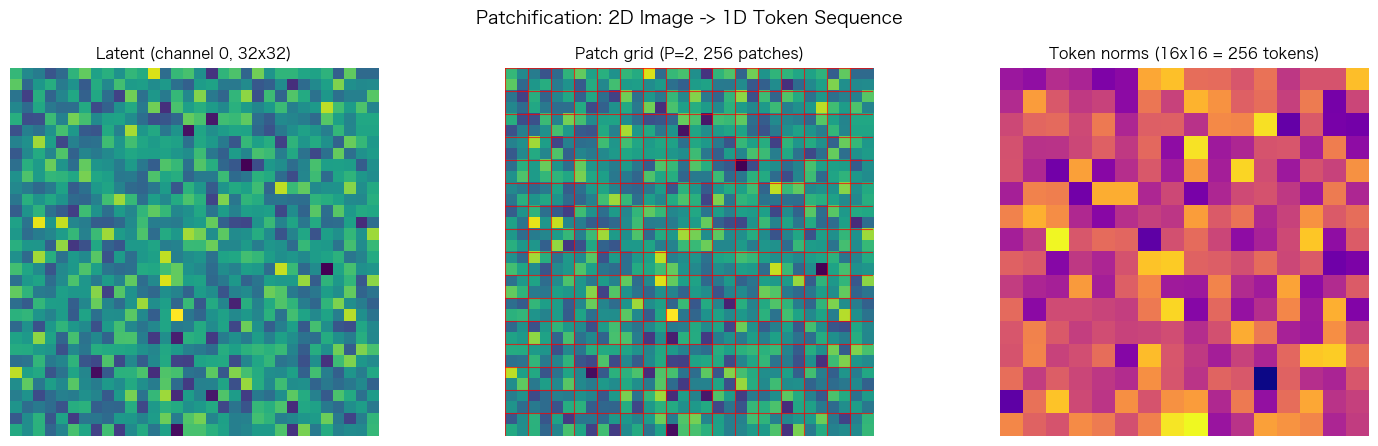

Patch Size,Tokens (32x32 latent),Tokens (64x64 latent),Quality,Speed
1x1,"1,024","4,096",Highest,Slowest (O(n^2) attention)
2x2,256,"1,024",High,Good balance
4x4,64,256,Medium,Fast
8x8,16,64,Lower,Very fast


In [4]:
# Visualize how patchification divides the image
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Original latent (show channel 0)
ax = axes[0]
img = latent[0, 0].detach().numpy()
ax.imshow(img, cmap='viridis')
ax.set_title('Latent (channel 0, 32x32)', fontsize=11, fontweight='bold')
ax.axis('off')

# Show patch grid overlay
ax = axes[1]
ax.imshow(img, cmap='viridis')
patch_size = 2
for i in range(0, 32, patch_size):
    ax.axhline(i - 0.5, color='red', linewidth=0.8, alpha=0.7)
    ax.axvline(i - 0.5, color='red', linewidth=0.8, alpha=0.7)
ax.set_title(f'Patch grid (P={patch_size}, {num_patches} patches)', fontsize=11, fontweight='bold')
ax.axis('off')

# Show tokens as 1D sequence
ax = axes[2]
token_norms = tokens[0].norm(dim=-1).detach().numpy()  # (256,)
token_grid = token_norms.reshape(num_patches_h, num_patches_w)
ax.imshow(token_grid, cmap='plasma')
ax.set_title(f'Token norms ({num_patches_h}x{num_patches_w} = {num_patches} tokens)', fontsize=11, fontweight='bold')
ax.axis('off')

plt.suptitle('Patchification: 2D Image -> 1D Token Sequence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Compare different patch sizes
comparison_table(
    headers=["Patch Size", "Tokens (32x32 latent)", "Tokens (64x64 latent)", "Quality", "Speed"],
    rows=[
        ["1x1", "1,024", "4,096", "Highest", "Slowest (O(n^2) attention)"],
        ["2x2", "256", "1,024", "High", "Good balance"],
        ["4x4", "64", "256", "Medium", "Fast"],
        ["8x8", "16", "64", "Lower", "Very fast"],
    ],
    title="Patch Size Tradeoff"
)

---
## 3. AdaLN-Zero 条件注入

在基于 UNet 的扩散模型中，我们通过**交叉注意力**（cross-attention）或直接添加嵌入来注入时间步和类别标签。DiT 引入了一种更优雅的方式：「自适应层归一化零初始化」（Adaptive Layer Normalization with Zero-initialization, AdaLN-Zero）。

核心思想：不通过单独的注意力层添加条件信息，而是直接**调制归一化参数本身**。Layer Normalization 有缩放参数 ($\gamma$) 和偏移参数 ($\beta$)。在 AdaLN 中，这些参数是由条件信号计算得到的：

$$\text{AdaLN}(h, c) = \gamma(c) \cdot \text{LayerNorm}(h) + \beta(c)$$

其中 $c$ 是条件向量（时间步 + 类别标签）。

**为什么叫"Zero"？** 缩放和偏移参数的初始化使得每个 DiT 模块最初充当一个**恒等函数**。这让训练更加稳定——模型一开始不做任何修改直接传递输入，然后逐渐学习如何调整它们。

In [5]:
class AdaLNZero(nn.Module):
    """Adaptive Layer Normalization with Zero-initialization.
    
    Modulates LayerNorm's scale and shift based on a conditioning vector.
    Also produces a gate parameter (alpha) for the residual connection.
    """
    def __init__(self, hidden_dim, cond_dim):
        super().__init__()
        self.norm = nn.LayerNorm(hidden_dim, elementwise_affine=False)
        # Predict 3 sets of parameters: gamma (scale), beta (shift), alpha (gate)
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(cond_dim, 3 * hidden_dim)
        )
        # Zero-initialize: initially gamma=1, beta=0, alpha=0
        # So the block starts as identity
        nn.init.zeros_(self.adaLN_modulation[1].weight)
        nn.init.zeros_(self.adaLN_modulation[1].bias)
    
    def forward(self, x, cond):
        """
        x: (B, N, D) -- input features
        cond: (B, D_cond) -- conditioning vector
        Returns: (normalized_x, gamma, beta, alpha)
        """
        # Predict modulation parameters from conditioning
        params = self.adaLN_modulation(cond)  # (B, 3*D)
        gamma, beta, alpha = params.chunk(3, dim=-1)  # each (B, D)
        
        # Apply adaptive layer norm
        x_norm = self.norm(x)
        # gamma and beta are broadcast over the sequence dimension
        x_modulated = (1 + gamma.unsqueeze(1)) * x_norm + beta.unsqueeze(1)
        
        return x_modulated, alpha

# Demo
torch.manual_seed(42)
hidden_dim = 128
cond_dim = 256
adaln = AdaLNZero(hidden_dim, cond_dim)

x = torch.randn(2, 64, hidden_dim)   # 2 batches, 64 tokens, 128-dim
cond = torch.randn(2, cond_dim)       # conditioning vector

x_mod, alpha = adaln(x, cond)

print(f"Input:       {list(x.shape)}")
print(f"Condition:   {list(cond.shape)}")
print(f"Output:      {list(x_mod.shape)}")
print(f"Gate (alpha): {list(alpha.shape)}")
print(f"\nAt initialization (zero-init):")
print(f"  gamma ~ 0 -> (1 + gamma) ~ 1 (identity scale)")
print(f"  beta  ~ 0 -> no shift")
print(f"  alpha ~ 0 -> residual gate is closed")
print(f"  gamma mean: {(1 + adaln.adaLN_modulation[1].bias[:hidden_dim]).mean().item():.4f} (should be ~1)")
print(f"  beta mean:  {adaln.adaLN_modulation[1].bias[hidden_dim:2*hidden_dim].mean().item():.6f} (should be ~0)")
print(f"  alpha mean: {adaln.adaLN_modulation[1].bias[2*hidden_dim:].mean().item():.6f} (should be ~0)")

Input:       [2, 64, 128]
Condition:   [2, 256]
Output:      [2, 64, 128]
Gate (alpha): [2, 128]

At initialization (zero-init):
  gamma ~ 0 -> (1 + gamma) ~ 1 (identity scale)
  beta  ~ 0 -> no shift
  alpha ~ 0 -> residual gate is closed
  gamma mean: 1.0000 (should be ~1)
  beta mean:  0.000000 (should be ~0)
  alpha mean: 0.000000 (should be ~0)


In [6]:
# Compare conditioning approaches
comparison_table(
    headers=["Method", "How it works", "Compute cost", "Used in"],
    rows=[
        ["Cross-Attention", "Separate Q/K/V attention layer between modalities", "O(N * M) where M = cond tokens", "Stable Diffusion UNet"],
        ["AdaLN-Zero", "Modulate normalization scale/shift from condition", "O(D) linear projection per layer", "DiT, FLUX"],
        ["In-Context", "Concatenate condition tokens with image tokens", "O((N+M)^2) -- increases sequence", "Some ViT approaches"],
        ["FiLM", "Predict scale/shift for each feature map", "O(D) -- similar to AdaLN", "Early conditional models"],
    ],
    title="Conditioning Mechanisms Comparison"
)

print("\nAdaLN-Zero is the cheapest option -- just a single linear projection per layer.")
print("Cross-attention is more expressive (good for text) but more expensive.")
print("DiT originally uses AdaLN-Zero for class-conditional generation.")
print("Later models (FLUX, SD3) combine both: AdaLN-Zero for timestep + cross-attention for text.")

Method,How it works,Compute cost,Used in
Cross-Attention,Separate Q/K/V attention layer between modalities,O(N * M) where M = cond tokens,Stable Diffusion UNet
AdaLN-Zero,Modulate normalization scale/shift from condition,O(D) linear projection per layer,"DiT, FLUX"
In-Context,Concatenate condition tokens with image tokens,O((N+M)^2) -- increases sequence,Some ViT approaches
FiLM,Predict scale/shift for each feature map,O(D) -- similar to AdaLN,Early conditional models



AdaLN-Zero is the cheapest option -- just a single linear projection per layer.
Cross-attention is more expressive (good for text) but more expensive.
DiT originally uses AdaLN-Zero for class-conditional generation.
Later models (FLUX, SD3) combine both: AdaLN-Zero for timestep + cross-attention for text.


---
## 4. DiT 模块和完整架构

DiT 模块本质上是一个标准的 Transformer 模块，只是用 AdaLN-Zero 替换了普通的 LayerNorm：

1. **AdaLN-Zero**（用时间步 + 类别条件进行调制）
2. **多头自注意力**（Multi-Head Self-Attention，和任何 Transformer 中的一样）
3. **残差连接**（由 AdaLN 的 alpha 门控）
4. **AdaLN-Zero**（再来一次）
5. **前馈网络**（FFN / MLP）
6. **残差连接**（由 alpha 门控）

完整的 DiT 架构：
1. 将输入图像图块化为 token 序列
2. 添加位置嵌入
3. 通过 N 个相同的 DiT 模块
4. 最终线性投影预测噪声（或速度）

In [7]:
class DiTBlock(nn.Module):
    """A single DiT block: self-attention + FFN, both with AdaLN-Zero conditioning."""
    def __init__(self, hidden_dim, n_heads, cond_dim, mlp_ratio=4.0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_heads = n_heads
        head_dim = hidden_dim // n_heads
        
        # AdaLN for attention: produces gamma1, beta1, alpha1
        self.adaLN_attn = AdaLNZero(hidden_dim, cond_dim)
        
        # Self-attention
        self.qkv = nn.Linear(hidden_dim, 3 * hidden_dim)
        self.attn_proj = nn.Linear(hidden_dim, hidden_dim)
        self.scale = head_dim ** -0.5
        
        # AdaLN for FFN: produces gamma2, beta2, alpha2
        self.adaLN_ffn = AdaLNZero(hidden_dim, cond_dim)
        
        # Feed-forward network
        mlp_hidden = int(hidden_dim * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden),
            nn.GELU(),
            nn.Linear(mlp_hidden, hidden_dim),
        )
    
    def forward(self, x, cond):
        """
        x: (B, N, D) -- token sequence
        cond: (B, D_cond) -- conditioning (timestep + class)
        """
        B, N, D = x.shape
        
        # --- Attention block ---
        x_mod, alpha1 = self.adaLN_attn(x, cond)
        
        # Multi-head self-attention
        qkv = self.qkv(x_mod).reshape(B, N, 3, self.n_heads, D // self.n_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn_out = (attn @ v).transpose(1, 2).reshape(B, N, D)
        attn_out = self.attn_proj(attn_out)
        
        # Gated residual: alpha controls how much this block contributes
        x = x + alpha1.unsqueeze(1) * attn_out
        
        # --- FFN block ---
        x_mod2, alpha2 = self.adaLN_ffn(x, cond)
        ffn_out = self.ffn(x_mod2)
        x = x + alpha2.unsqueeze(1) * ffn_out
        
        return x

# Demo: forward pass with real tensors
torch.manual_seed(42)
hidden_dim = 256
n_heads = 8
cond_dim = 512

block = DiTBlock(hidden_dim, n_heads, cond_dim)
x = torch.randn(2, 64, hidden_dim)   # 64 tokens
cond = torch.randn(2, cond_dim)

out = block(x, cond)
print(f"Input:  {list(x.shape)}")
print(f"Output: {list(out.shape)}")
print(f"\nDiT block parameters: {sum(p.numel() for p in block.parameters()):,}")
print(f"  Attention (QKV + proj): {sum(p.numel() for n, p in block.named_parameters() if 'qkv' in n or 'attn_proj' in n):,}")
print(f"  FFN:                    {sum(p.numel() for n, p in block.named_parameters() if 'ffn' in n):,}")
print(f"  AdaLN (conditioning):   {sum(p.numel() for n, p in block.named_parameters() if 'adaLN' in n):,}")

Input:  [2, 64, 256]
Output: [2, 64, 256]

DiT block parameters: 1,576,704
  Attention (QKV + proj): 263,168
  FFN:                    919,552
  AdaLN (conditioning):   787,968


In [8]:
class SimpleDiT(nn.Module):
    """Simplified Diffusion Transformer."""
    def __init__(self, in_channels=4, patch_size=2, hidden_dim=256, 
                 depth=6, n_heads=8, num_classes=10, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        # Patchify
        self.patch_embed = PatchEmbed(in_channels, patch_size, hidden_dim)
        
        # Positional embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, hidden_dim))
        nn.init.normal_(self.pos_embed, std=0.02)
        
        # Conditioning: timestep + class label -> cond vector
        cond_dim = hidden_dim * 2
        self.time_embed = nn.Sequential(
            nn.Linear(hidden_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )
        self.class_embed = nn.Embedding(num_classes, cond_dim)
        
        # DiT blocks
        self.blocks = nn.ModuleList([
            DiTBlock(hidden_dim, n_heads, cond_dim) for _ in range(depth)
        ])
        
        # Final layer: AdaLN + linear to predict noise
        self.final_norm = nn.LayerNorm(hidden_dim, elementwise_affine=False)
        self.final_adaLN = nn.Sequential(nn.SiLU(), nn.Linear(cond_dim, 2 * hidden_dim))
        self.final_proj = nn.Linear(hidden_dim, patch_size * patch_size * in_channels)
        nn.init.zeros_(self.final_proj.weight)
        nn.init.zeros_(self.final_proj.bias)
    
    def unpatchify(self, x, H, W):
        """Convert patch tokens back to spatial image."""
        B, N, patch_vals = x.shape
        p = self.patch_size
        C = patch_vals // (p * p)
        h, w = H // p, W // p
        x = x.reshape(B, h, w, p, p, C)
        x = x.permute(0, 5, 1, 3, 2, 4).reshape(B, C, H, W)
        return x
    
    def timestep_embedding(self, t, dim):
        """Sinusoidal timestep embedding (same as in Transformers)."""
        half = dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None]
        return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    
    def forward(self, x, t, y):
        """
        x: (B, C, H, W) noisy latent
        t: (B,) timestep indices
        y: (B,) class labels
        """
        B, C, H, W = x.shape
        
        # Patchify
        tokens = self.patch_embed(x) + self.pos_embed  # (B, N, D)
        
        # Conditioning
        t_emb = self.timestep_embedding(t, self.blocks[0].hidden_dim)
        cond = self.time_embed(t_emb) + self.class_embed(y)  # (B, cond_dim)
        
        # DiT blocks
        for block in self.blocks:
            tokens = block(tokens, cond)
        
        # Final layer
        params = self.final_adaLN(cond)
        gamma, beta = params.chunk(2, dim=-1)
        tokens = (1 + gamma.unsqueeze(1)) * self.final_norm(tokens) + beta.unsqueeze(1)
        tokens = self.final_proj(tokens)  # (B, N, p*p*C)
        
        # Unpatchify
        noise_pred = self.unpatchify(tokens, H, W)
        return noise_pred

# Instantiate and test
torch.manual_seed(42)
model = SimpleDiT(in_channels=4, patch_size=2, hidden_dim=256, depth=6, n_heads=8, 
                  num_classes=10, img_size=32)

x = torch.randn(2, 4, 32, 32)     # noisy latent
t = torch.tensor([100, 500])       # timesteps
y = torch.tensor([3, 7])           # class labels

with torch.no_grad():
    noise_pred = model(x, t, y)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nForward pass:")
print(f"  Input (noisy latent): {list(x.shape)}")
print(f"  Timestep:             {list(t.shape)} -> sinusoidal embed -> conditioning")
print(f"  Class label:          {list(y.shape)} -> class embed -> conditioning")
print(f"  Patchified tokens:    [{2}, {model.num_patches}, {256}]")
print(f"  After {6} DiT blocks:  [{2}, {model.num_patches}, {256}]")
print(f"  Output (pred noise):  {list(noise_pred.shape)} (same shape as input)")

Model parameters: 10,196,240

Forward pass:
  Input (noisy latent): [2, 4, 32, 32]
  Timestep:             [2] -> sinusoidal embed -> conditioning
  Class label:          [2] -> class embed -> conditioning
  Patchified tokens:    [2, 256, 256]
  After 6 DiT blocks:  [2, 256, 256]
  Output (pred noise):  [2, 4, 32, 32] (same shape as input)


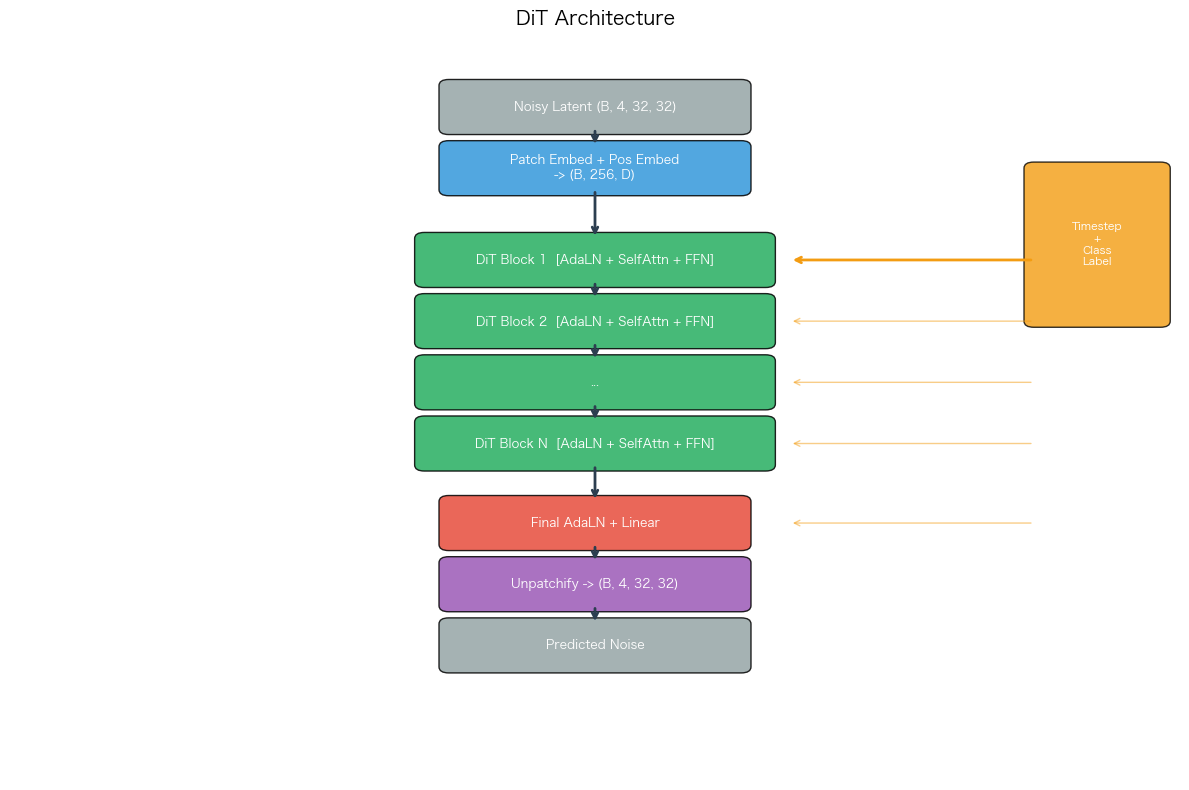

Key observation: every DiT block is identical.
This uniformity is what makes DiT so compatible with parallelism techniques.


In [9]:
# DiT architecture diagram
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_title('DiT Architecture', fontsize=14, fontweight='bold', pad=15)

# Components top to bottom
components = [
    (6, 11, 3, 0.7, 'Noisy Latent (B, 4, 32, 32)', '#95A5A6'),
    (6, 10, 3, 0.7, 'Patch Embed + Pos Embed\n-> (B, 256, D)', '#3498DB'),
    (6, 8.5, 3.5, 0.7, 'DiT Block 1  [AdaLN + SelfAttn + FFN]', '#27AE60'),
    (6, 7.5, 3.5, 0.7, 'DiT Block 2  [AdaLN + SelfAttn + FFN]', '#27AE60'),
    (6, 6.5, 3.5, 0.7, '...', '#27AE60'),
    (6, 5.5, 3.5, 0.7, 'DiT Block N  [AdaLN + SelfAttn + FFN]', '#27AE60'),
    (6, 4.2, 3, 0.7, 'Final AdaLN + Linear', '#E74C3C'),
    (6, 3.2, 3, 0.7, 'Unpatchify -> (B, 4, 32, 32)', '#9B59B6'),
    (6, 2.2, 3, 0.7, 'Predicted Noise', '#95A5A6'),
]

for x, y, w, h, label, color in components:
    rect = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
                                     boxstyle="round,pad=0.1", facecolor=color, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=9, color='white', fontweight='bold')

# Arrows between components
for i in range(len(components) - 1):
    y1 = components[i][1] - components[i][3]/2
    y2 = components[i+1][1] + components[i+1][3]/2
    ax.annotate('', xy=(6, y2), xytext=(6, y1),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=2))

# Conditioning input
ax.annotate('', xy=(8, 8.5), xytext=(10.5, 8.5),
            arrowprops=dict(arrowstyle='->', color='#F39C12', lw=2))
rect = mpatches.FancyBboxPatch((10.5, 7.5), 1.3, 2.5,
                                 boxstyle="round,pad=0.1", facecolor='#F39C12', alpha=0.8)
ax.add_patch(rect)
ax.text(11.15, 8.75, 'Timestep\n+\nClass\nLabel', ha='center', va='center', 
        fontsize=8, color='white', fontweight='bold')

# Arrow from conditioning to other blocks
for y in [7.5, 6.5, 5.5, 4.2]:
    ax.annotate('', xy=(8, y), xytext=(10.5, y),
                arrowprops=dict(arrowstyle='->', color='#F39C12', lw=1, alpha=0.5))

plt.tight_layout()
plt.show()

print("Key observation: every DiT block is identical.")
print("This uniformity is what makes DiT so compatible with parallelism techniques.")

---
## 5. 扩展性分析

DiT 有四种规模，沿用 ViT 的命名惯例：

| 模型 | 隐藏维度 | 注意力头数 | 层数 | 参数量 | GFLOPs (256x256) |
|------|---------|-----------|------|--------|------------------|
| DiT-S/2 | 384 | 6 | 12 | 33M | 6 |
| DiT-B/2 | 768 | 12 | 12 | 130M | 23 |
| DiT-L/2 | 1024 | 16 | 24 | 458M | 80 |
| DiT-XL/2 | 1152 | 16 | 28 | 675M | 119 |

"/2"表示 patch 大小 = 2。更小的 patch = 更多的 token = 更多计算但质量更好。

DiT 论文的核心发现：**扩展是可预测的**。模型规模翻倍后，FID 分数持续改善，遵循平滑的幂律——就像大语言模型的 scaling law 一样。

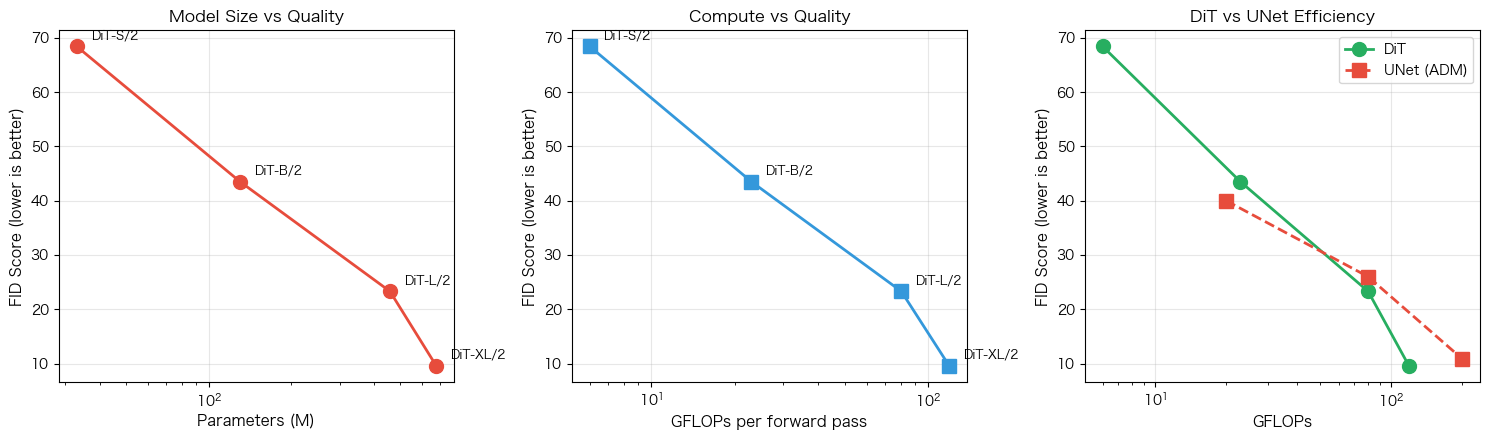

Key insight: DiT achieves comparable quality to UNet with fewer GFLOPs,
and its scaling curve is smoother and more predictable.


In [10]:
# DiT scaling: model size vs compute vs quality
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Model configurations
models = ['DiT-S/2', 'DiT-B/2', 'DiT-L/2', 'DiT-XL/2']
params = [33, 130, 458, 675]  # millions
gflops = [6, 23, 80, 119]
fid_scores = [68.4, 43.5, 23.3, 9.62]  # ImageNet 256x256 (from DiT paper, cfg=1.5)

# Params vs FID
axes[0].plot(params, fid_scores, 'o-', color='#E74C3C', markersize=10, linewidth=2)
for i, model in enumerate(models):
    axes[0].annotate(model, (params[i], fid_scores[i]), textcoords="offset points",
                     xytext=(10, 5), fontsize=9)
axes[0].set_xlabel('Parameters (M)', fontsize=11)
axes[0].set_ylabel('FID Score (lower is better)', fontsize=11)
axes[0].set_title('Model Size vs Quality', fontsize=12, fontweight='bold')
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)

# GFLOPs vs FID
axes[1].plot(gflops, fid_scores, 's-', color='#3498DB', markersize=10, linewidth=2)
for i, model in enumerate(models):
    axes[1].annotate(model, (gflops[i], fid_scores[i]), textcoords="offset points",
                     xytext=(10, 5), fontsize=9)
axes[1].set_xlabel('GFLOPs per forward pass', fontsize=11)
axes[1].set_ylabel('FID Score (lower is better)', fontsize=11)
axes[1].set_title('Compute vs Quality', fontsize=12, fontweight='bold')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

# Compare with UNet at similar compute
dit_compute = [6, 23, 80, 119]
dit_fid = [68.4, 43.5, 23.3, 9.62]
# UNet reference points (approximate from ADM paper)
unet_compute = [20, 80, 200]
unet_fid = [40, 26, 10.9]

axes[2].plot(dit_compute, dit_fid, 'o-', color='#27AE60', markersize=10, linewidth=2, label='DiT')
axes[2].plot(unet_compute, unet_fid, 's--', color='#E74C3C', markersize=10, linewidth=2, label='UNet (ADM)')
axes[2].set_xlabel('GFLOPs', fontsize=11)
axes[2].set_ylabel('FID Score (lower is better)', fontsize=11)
axes[2].set_title('DiT vs UNet Efficiency', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].set_xscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key insight: DiT achieves comparable quality to UNet with fewer GFLOPs,")
print("and its scaling curve is smoother and more predictable.")

---
## 6. 工程视角：为什么视频生成选择 DiT

DiT 的统一架构不只是优雅——它在工程上有深远的意义，尤其是在训练大规模视频生成模型时：

### 为什么 DiT 更适合并行化：

1. **没有跨阶段的跳跃连接**：UNet 的跳跃连接要求编码器完成后解码器才能开始，限制了流水线并行。DiT 的模块是顺序执行的，没有长距离依赖。

2. **每层计算量均匀**：每个 DiT 模块的 FLOPs 相同。这意味着你可以把层均匀地分配到各个 GPU 上——没有负载均衡问题。

3. **标准 Transformer 基础设施**：FlashAttention、张量并行以及所有为 LLM 训练构建的优化手段，都可以直接用在 DiT 上。

这正是 [流水线并行](../../en/03-pipeline-parallelism.ipynb) 与 DiT 完美配合的原因：你可以把 N 个模块分成 P 个流水线阶段，每个阶段包含 N/P 个模块，而且每个阶段的计算量完全相同。

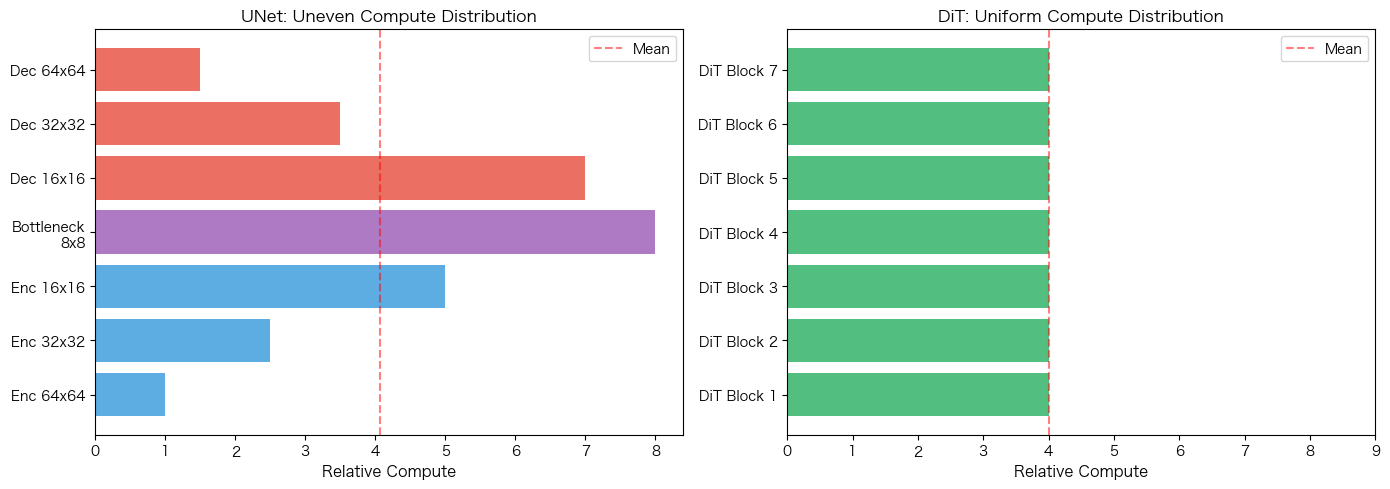

For 4-GPU pipeline parallelism:
  UNet: some GPUs get 8.0x more compute -> idle time
  DiT:  all GPUs get identical compute -> perfect load balance


In [11]:
# Why DiT is better for parallelism: compute distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# UNet: uneven compute per stage (encoder lighter, decoder heavier due to skip concat)
ax = axes[0]
unet_stages = ['Enc 64x64', 'Enc 32x32', 'Enc 16x16', 'Bottleneck\n8x8', 
               'Dec 16x16', 'Dec 32x32', 'Dec 64x64']
# Relative compute (decoder is heavier due to concatenated skip connections)
unet_compute = [1.0, 2.5, 5.0, 8.0, 7.0, 3.5, 1.5]
colors_unet = ['#3498DB']*3 + ['#9B59B6'] + ['#E74C3C']*3
ax.barh(unet_stages, unet_compute, color=colors_unet, alpha=0.8)
ax.set_xlabel('Relative Compute', fontsize=11)
ax.set_title('UNet: Uneven Compute Distribution', fontsize=12, fontweight='bold')
ax.axvline(x=np.mean(unet_compute), color='red', linestyle='--', alpha=0.5, label='Mean')
ax.legend()

# DiT: uniform compute per layer
ax = axes[1]
n_layers = 7
dit_stages = [f'DiT Block {i+1}' for i in range(n_layers)]
dit_compute = [4.0] * n_layers  # all identical
ax.barh(dit_stages, dit_compute, color='#27AE60', alpha=0.8)
ax.set_xlabel('Relative Compute', fontsize=11)
ax.set_title('DiT: Uniform Compute Distribution', fontsize=12, fontweight='bold')
ax.axvline(x=4.0, color='red', linestyle='--', alpha=0.5, label='Mean')
ax.set_xlim(0, max(unet_compute) + 1)
ax.legend()

plt.tight_layout()
plt.show()

print("For 4-GPU pipeline parallelism:")
print(f"  UNet: some GPUs get {max(unet_compute)/min(unet_compute):.1f}x more compute -> idle time")
print(f"  DiT:  all GPUs get identical compute -> perfect load balance")

In [12]:
info_box(
    """<b>DiT 在现代生产级模型中的应用</b><br><br>
    DiT 的架构（及其变体）已经成为最先进生成模型的骨干网络：
    <ul>
    <li><b>Sora</b>（OpenAI）：用于视频生成的时空 DiT</li>
    <li><b>FLUX</b>（Black Forest Labs）：带联合注意力的改进版 DiT，用于文生图</li>
    <li><b>Stable Diffusion 3</b>（Stability AI）：MMDiT（多模态 DiT），文本和图像分别处理</li>
    <li><b>HunyuanVideo</b>（腾讯）：基于 DiT 的视频生成架构</li>
    <li><b>CogVideo</b>（智谱 AI）：用于视频的专家 Transformer</li>
    </ul>
    共同点：它们都用某种形式的 Transformer 替换了 UNet，从而实现了大规模训练。""",
    title="实际影响"
)

In [13]:
# Compute DiT FLOPs breakdown
def dit_flops(hidden_dim, n_heads, depth, num_patches, mlp_ratio=4.0):
    """Estimate FLOPs for a single forward pass of DiT."""
    D = hidden_dim
    N = num_patches
    
    # Per block:
    # QKV projection: 3 * 2 * N * D * D
    qkv_flops = 3 * 2 * N * D * D
    # Attention: 2 * N * N * D (QK^T + AV)
    attn_flops = 2 * N * N * D
    # Output projection: 2 * N * D * D
    out_proj_flops = 2 * N * D * D
    # FFN: 2 * 2 * N * D * (D * mlp_ratio)
    ffn_flops = 2 * 2 * N * D * int(D * mlp_ratio)
    # AdaLN: small, ignore
    
    block_flops = qkv_flops + attn_flops + out_proj_flops + ffn_flops
    total_flops = block_flops * depth
    
    return total_flops, block_flops, {
        'QKV': qkv_flops, 'Attention': attn_flops, 
        'OutProj': out_proj_flops, 'FFN': ffn_flops
    }

configs = {
    'DiT-S/2': (384, 6, 12),
    'DiT-B/2': (768, 12, 12),
    'DiT-L/2': (1024, 16, 24),
    'DiT-XL/2': (1152, 16, 28),
}

print(f"{'Model':<12} | {'Total GFLOPs':>12} | {'Attn %':>8} | {'FFN %':>8} | {'QKV %':>8}")
print("-" * 60)

for name, (D, H, L) in configs.items():
    N = 256  # patches for 32x32 latent with P=2; paper uses 256x256 images
    # For 256x256 image with P=2: latent is 32x32, patches = 16x16 = 256
    total, block, breakdown = dit_flops(D, H, L, N)
    total_gflops = total / 1e9
    attn_pct = breakdown['Attention'] / (total / L) * 100
    ffn_pct = breakdown['FFN'] / (total / L) * 100
    qkv_pct = breakdown['QKV'] / (total / L) * 100
    print(f"{name:<12} | {total_gflops:>10.1f} G | {attn_pct:>6.1f}% | {ffn_pct:>6.1f}% | {qkv_pct:>6.1f}%")

print("\nFFN dominates compute (~65-75%). This is true for LLMs too, which is why")
print("tensor parallelism (splitting the FFN across GPUs) is so effective.")

Model        | Total GFLOPs |   Attn % |    FFN % |    QKV %
------------------------------------------------------------
DiT-S/2      |       11.5 G |    5.3% |   63.2% |   23.7%
DiT-B/2      |       44.7 G |    2.7% |   64.9% |   24.3%
DiT-L/2      |      157.8 G |    2.0% |   65.3% |   24.5%
DiT-XL/2     |      232.5 G |    1.8% |   65.5% |   24.5%

FFN dominates compute (~65-75%). This is true for LLMs too, which is why
tensor parallelism (splitting the FFN across GPUs) is so effective.


---
## 总结

| 概念 | 核心思想 |
|------|---------|
| **图块化（Patchification）** | 将二维图像转换为一维 token 序列（就像 ViT） |
| **AdaLN-Zero** | 通过调制 LayerNorm 来注入条件——轻量且高效 |
| **DiT 模块** | 带有 AdaLN-Zero 条件注入的标准 Transformer 模块 |
| **扩展性** | 可预测的幂律性能提升 |
| **并行化** | 均匀的层结构让张量 / 流水线并行变得轻松 |

### 要点回顾
- DiT 用简单重复的 Transformer 模块替换了 UNet 复杂的多分辨率架构
- AdaLN-Zero 是一种轻量级的条件注入机制，通过调制归一化参数实现
- 统一的架构使得跨多个 GPU 的高效并行成为可能
- DiT 继承了 LLM 研究中所有的扩展特性和基础设施优化

### 延伸阅读
- [Scalable Diffusion Models with Transformers (Peebles & Xie, 2023)](https://arxiv.org/abs/2212.09748)
- [FLUX.1 Technical Report (Black Forest Labs, 2024)](https://blackforestlabs.ai/)
- [Scaling Rectified Flow Transformers for High-Resolution Image Synthesis (SD3)](https://arxiv.org/abs/2403.03206)

### 下一节：[05 - 视频生成](05-video-generation.ipynb)——将扩散模型扩展到时间维度